# 🇧🇯 GDELT × Bénin — Exploration des données
**Hackathon iSHEERO × DataCamp 2026**

Ce notebook te guide pas à pas pour :
1. Te connecter à Google BigQuery
2. Extraire les données GDELT sur le Bénin (12 derniers mois)
3. Explorer et nettoyer les données
4. Produire tes premières visualisations

---
> ⚠️ **Prérequis** : avoir un compte Google avec BigQuery activé (gratuit jusqu'à 1 TB/mois)

## 📦 Cellule 1 — Installation des dépendances

In [28]:
!pip install google-cloud-bigquery google-auth pandas matplotlib seaborn plotly db-dtypes --quiet
print('✅ Installation terminée !')

✅ Installation terminée !


## 🔑 Cellule 2 — Authentification Google BigQuery

**Comment obtenir ton fichier de clé JSON :**
1. Va sur [console.cloud.google.com](https://console.cloud.google.com)
2. Crée un projet (ou utilise un existant) et active l'API BigQuery
3. Va dans **IAM & Admin → Comptes de service → Créer**
4. Donne le rôle **BigQuery User** + **BigQuery Job User**
5. Crée une clé JSON, télécharge-la et place-la dans le même dossier que ce notebook

In [29]:
import os
if 'GOOGLE_APPLICATION_CREDENTIALS' in os.environ:
    del os.environ['GOOGLE_APPLICATION_CREDENTIALS']
print("🧹 Nettoyé !")

🧹 Nettoyé !


In [30]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="gdelt-hackathon16")
print("✅ Connecté au projet : gdelt-hackathon16")

# ⚠️ Ne JAMAIS faire SELECT * sur GDELT — trop coûteux
# Toujours lister uniquement les colonnes nécessaires
query = """
SELECT
    SQLDATE,
    Actor1Name,
    Actor1CountryCode,
    Actor1Type1Code,
    Actor2Name,
    Actor2CountryCode,
    Actor2Type1Code,
    EventCode,
    EventRootCode,
    QuadClass,
    GoldsteinScale,
    NumMentions,
    NumSources,
    NumArticles,
    AvgTone,
    Actor1Geo_FullName,
    Actor1Geo_Lat,
    Actor1Geo_Long,
    Actor2Geo_FullName,
    Actor2Geo_Lat,
    Actor2Geo_Long,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    ActionGeo_ADM1Code,
    ActionGeo_Lat,
    ActionGeo_Long,
    SOURCEURL
FROM `gdelt-bq.gdeltv2.events`
WHERE Year = 2025                        -- ← Year EN PREMIER (économise 90% du quota)
  AND ActionGeo_CountryCode = 'BN'
LIMIT 10000
"""

print("⏳ Requête en cours...")
df_benin = client.query(query).to_dataframe()
print(f"✅ {len(df_benin):,} événements chargés !")
print("Dimensions :", df_benin.shape)
df_benin.head()

✅ Connecté au projet : gdelt-hackathon16
⏳ Requête en cours...


Forbidden: 403 Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas; reason: quotaExceeded, location: unbilled.analysis, message: Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas

Location: US
Job ID: c65f78a1-620a-4ac4-8690-4bdc9a55a899


## 🗄️ Cellule 3 — Les colonnes GDELT importantes à connaître

| Colonne | Description |
|---|---|
| `SQLDATE` | Date de l'événement (format YYYYMMDD) |
| `Actor1Name` / `Actor2Name` | Acteurs impliqués |
| `EventCode` | Code CAMEO précis de l'action |
| `EventRootCode` | Catégorie principale (01=coopération … 20=force) |
| `ActionGeo_CountryCode` | Code pays (`BN` = Bénin) |
| `ActionGeo_Lat` / `ActionGeo_Long` | Coordonnées GPS |
| `AvgTone` | Ton de l'article (négatif = mauvais, positif = bon) |
| `NumArticles` | Nombre d'articles couvrant l'événement |
| `GoldsteinScale` | Stabilité (-10 = déstabilisant, +10 = coopératif) |

## 📥 Cellule 4 — Extraction des données Bénin (2025)

In [ ]:
import pandas as pd

# ⚠️ Toujours filtrer sur YEAR en premier pour économiser le quota BigQuery
query = """
SELECT
    SQLDATE,
    Actor1Name,
    Actor1CountryCode,
    Actor2Name,
    Actor2CountryCode,
    EventCode,
    EventRootCode,
    ActionGeo_CountryCode,
    ActionGeo_Lat,
    ActionGeo_Long,
    ActionGeo_FullName,
    AvgTone,
    NumArticles,
    GoldsteinScale,
    SOURCEURL
FROM `gdelt-bq.gdeltv2.events`
WHERE
    YEAR >= 2025
    AND ActionGeo_CountryCode = 'BN'
    AND SQLDATE >= 20250101
LIMIT 50000
"""

print('⏳ Requête en cours... (peut prendre 10-30 secondes)')
df = client.query(query).to_dataframe()
print(f'✅ {len(df):,} événements extraits !')
df.head()

## 🔍 Cellule 5 — Première exploration : dimensions, types, valeurs manquantes

In [16]:
print('=' * 55)
print(f'📊 Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print('=' * 55)

print('\n📋 Types de colonnes :')
print(df.dtypes)

print('\n❓ Valeurs manquantes :')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Manquants': missing, '% manquant': missing_pct})
print(missing_df[missing_df['Manquants'] > 0].sort_values('% manquant', ascending=False))

print('\n📈 Statistiques descriptives :')
df[['AvgTone', 'GoldsteinScale', 'NumArticles']].describe().round(2)

📊 Dimensions : 30,445 lignes × 15 colonnes

📋 Types de colonnes :
SQLDATE                    Int64
Actor1Name                object
Actor1CountryCode         object
Actor2Name                object
Actor2CountryCode         object
EventCode                 object
EventRootCode             object
ActionGeo_CountryCode     object
ActionGeo_Lat            float64
ActionGeo_Long           float64
ActionGeo_FullName        object
AvgTone                  float64
NumArticles                Int64
GoldsteinScale           float64
SOURCEURL                 object
dtype: object

❓ Valeurs manquantes :
                   Manquants  % manquant
Actor2CountryCode      17733        58.2
Actor1CountryCode      14940        49.1
Actor2Name              9370        30.8
Actor1Name              2892         9.5

📈 Statistiques descriptives :


,AvgTone,GoldsteinScale,NumArticles
count,30445.00,30445.00,30445.0
mean,-1.61,0.49,5.77
std,4.58,4.58,3.78
min,-18.52,-10.00,1.0
25%,-4.94,-2.00,2.0
50%,-1.45,1.90,5.0
75%,1.79,3.40,10.0
max,19.48,10.00,48.0


## 🧹 Cellule 6 — Nettoyage et enrichissement des données

In [17]:
# Convertir SQLDATE en datetime
df['date']     = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')
df['mois_nom'] = df['date'].dt.strftime('%b %Y')
df['semaine']  = df['date'].dt.isocalendar().week.astype(int)

# Labels lisibles pour les codes CAMEO
cameo_labels = {
    '01': 'Déclarations publiques',    '02': 'Appels / demandes',
    '03': 'Expressions d intention',   '04': 'Consultations',
    '05': 'Engagement diplomatique',   '06': 'Coopération matérielle',
    '07': 'Aide fournie',              '08': 'Céder / coopérer',
    '09': 'Médiation',                 '10': 'Demandes / propositions',
    '11': 'Désapprobation',            '12': 'Rejet',
    '13': 'Menace',                    '14': 'Protestation',
    '15': 'Coercition',                '16': 'Attaque militaire',
    '17': 'Violence non militaire',    '18': 'Assaut',
    '19': 'Violence de masse',         '20': 'Usage de la force'
}
df['categorie_event'] = df['EventRootCode'].map(cameo_labels).fillna('Autre')

# Classifier le ton
df['ton_label'] = pd.cut(
    df['AvgTone'],
    bins=[-100, -5, -1, 1, 5, 100],
    labels=['Très négatif', 'Négatif', 'Neutre', 'Positif', 'Très positif']
)

# Dataset avec GPS uniquement
df_geo = df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']).copy()

# Créer dossier data
import os
os.makedirs('data', exist_ok=True)

print(f'✅ Nettoyage terminé !')
print(f'   Dataset principal : {len(df):,} lignes')
print(f'   Dataset avec GPS  : {len(df_geo):,} lignes')
print(f'   Période           : {df["date"].min().date()} → {df["date"].max().date()}')

✅ Nettoyage terminé !
   Dataset principal : 30,445 lignes
   Dataset avec GPS  : 30,445 lignes
   Période           : 2025-01-01 → 2026-04-28


## 📊 Cellule 7 — Visualisation 1 : Volume d'événements par mois

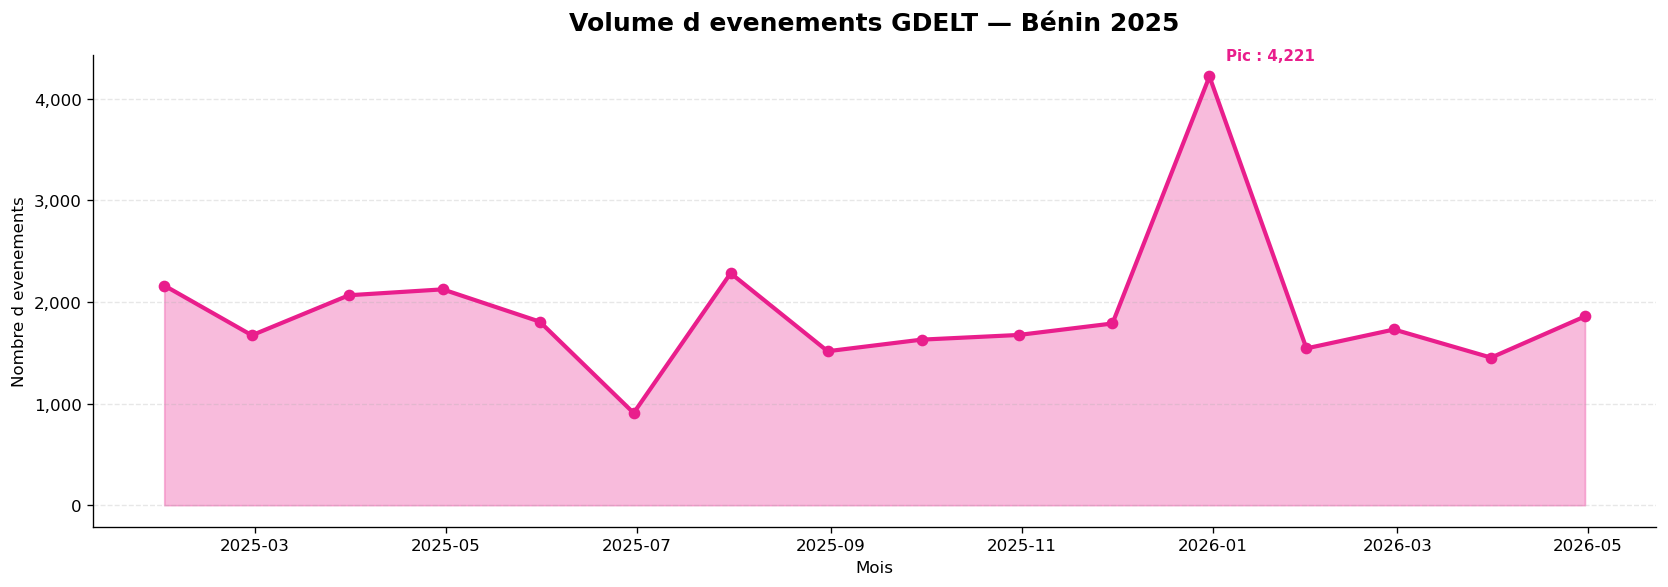

✅ viz1 sauvegardée


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

events_par_mois = df.set_index('date').resample('ME').size().reset_index()
events_par_mois.columns = ['date', 'nb_events']

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(events_par_mois['date'], events_par_mois['nb_events'], alpha=0.3, color='#E91E8C')
ax.plot(events_par_mois['date'], events_par_mois['nb_events'],
        color='#E91E8C', linewidth=2.5, marker='o', markersize=6)

# Annoter le pic
max_idx = events_par_mois['nb_events'].idxmax()
max_row = events_par_mois.loc[max_idx]
ax.annotate(f'Pic : {max_row["nb_events"]:,}',
            xy=(max_row['date'], max_row['nb_events']),
            xytext=(10, 10), textcoords='offset points',
            fontsize=9, color='#E91E8C', fontweight='bold')

ax.set_title('Volume d evenements GDELT — Bénin 2025', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Mois'); ax.set_ylabel('Nombre d evenements')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_volume_evenements.png', bbox_inches='tight')
plt.show()
print('✅ viz1 sauvegardée')

## 📊 Cellule 8 — Visualisation 2 : Top 10 des types d'événements

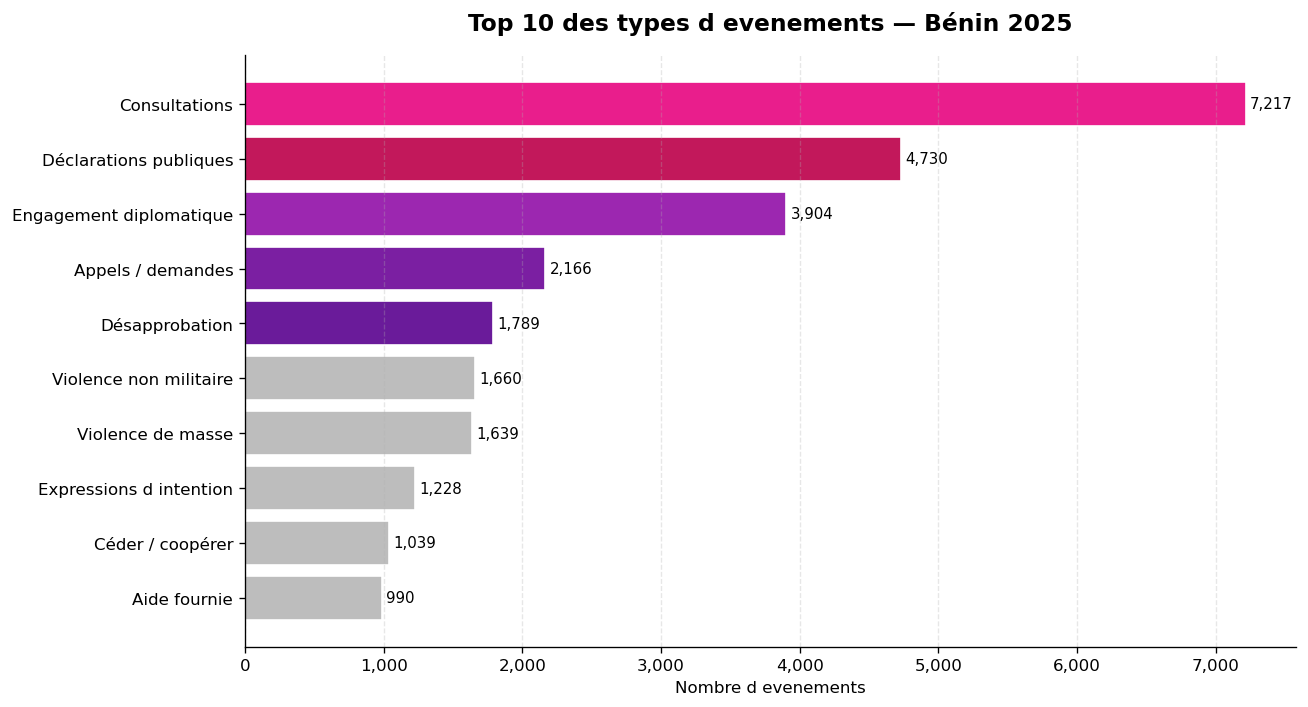

✅ viz2 sauvegardée


In [20]:
top_categories = df['categorie_event'].value_counts().head(10)
colors = ['#E91E8C','#C2185B','#9C27B0','#7B1FA2','#6A1B9A','#BDBDBD','#BDBDBD','#BDBDBD','#BDBDBD','#BDBDBD']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_categories.index[::-1], top_categories.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, top_categories.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 10 des types d evenements — Bénin 2025', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nombre d evenements')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_types_evenements.png', bbox_inches='tight')
plt.show()
print('✅ viz2 sauvegardée')

## 📊 Cellule 9 — Visualisation 3 : Évolution du ton médiatique (AvgTone)

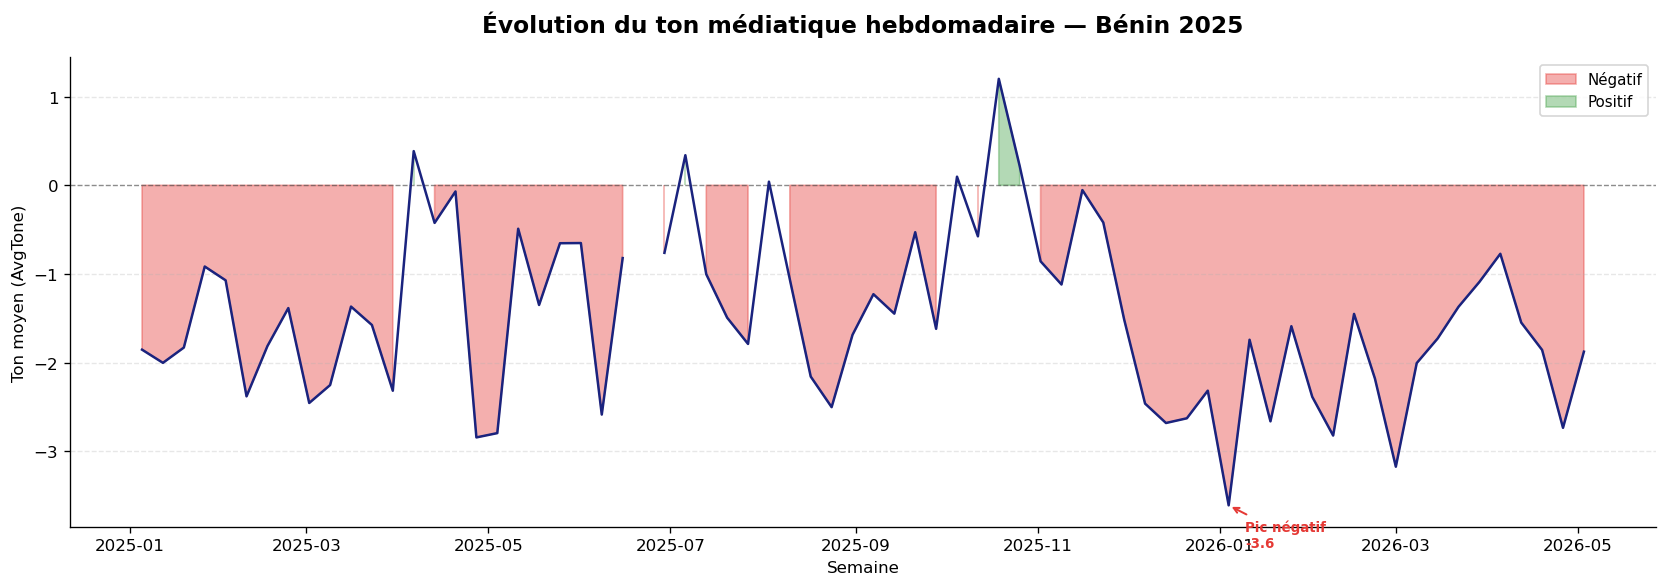

✅ viz3 sauvegardée


In [21]:
ton_hebdo = df.set_index('date')['AvgTone'].resample('W').mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color='#333', linewidth=0.8, linestyle='--', alpha=0.5)
ax.fill_between(ton_hebdo['date'], ton_hebdo['AvgTone'], 0,
                where=(ton_hebdo['AvgTone'] < 0), color='#E53935', alpha=0.4, label='Négatif')
ax.fill_between(ton_hebdo['date'], ton_hebdo['AvgTone'], 0,
                where=(ton_hebdo['AvgTone'] >= 0), color='#43A047', alpha=0.4, label='Positif')
ax.plot(ton_hebdo['date'], ton_hebdo['AvgTone'], color='#1A237E', linewidth=1.5)

# Pic le plus négatif
min_idx = ton_hebdo['AvgTone'].idxmin()
min_row = ton_hebdo.loc[min_idx]
ax.annotate(f'Pic négatif\n{min_row["AvgTone"]:.1f}',
            xy=(min_row['date'], min_row['AvgTone']),
            xytext=(10, -25), textcoords='offset points',
            fontsize=8, color='#E53935', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2))

ax.set_title('Évolution du ton médiatique hebdomadaire — Bénin 2025', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Semaine'); ax.set_ylabel('Ton moyen (AvgTone)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_ton_mediatique.png', bbox_inches='tight')
plt.show()
print('✅ viz3 sauvegardée')

## 📊 Cellule 10 — Visualisation 4 : Score de stabilité par catégorie (GoldsteinScale)

C:\Users\USER\AppData\Local\Temp\ipykernel_23436\1639609431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top8, y='categorie_event', x='GoldsteinScale',


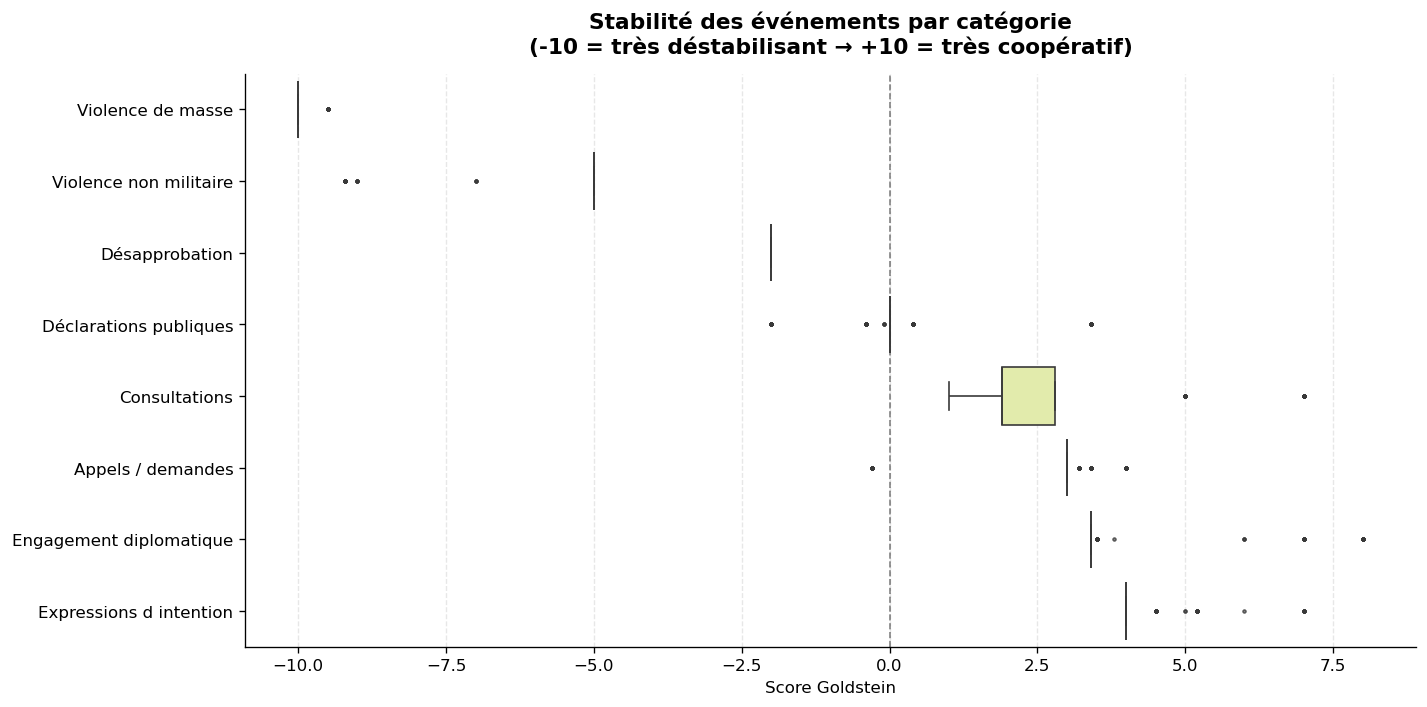

✅ viz4 sauvegardée


In [22]:
import seaborn as sns

top8 = df['categorie_event'].value_counts().head(8).index.tolist()
df_top8 = df[df['categorie_event'].isin(top8)]
order = df_top8.groupby('categorie_event')['GoldsteinScale'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_top8, y='categorie_event', x='GoldsteinScale',
            order=order, palette='RdYlGn', ax=ax,
            flierprops=dict(marker='.', markersize=3, alpha=0.3))
ax.axvline(0, color='#333', linewidth=1, linestyle='--', alpha=0.6)
ax.set_title('Stabilité des événements par catégorie\n'
             '(-10 = très déstabilisant → +10 = très coopératif)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Score Goldstein'); ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz4_goldstein_categories.png', bbox_inches='tight')
plt.show()
print('✅ viz4 sauvegardée')

## 📊 Cellule 11 — Visualisation 5 : Top 15 des acteurs mentionnés

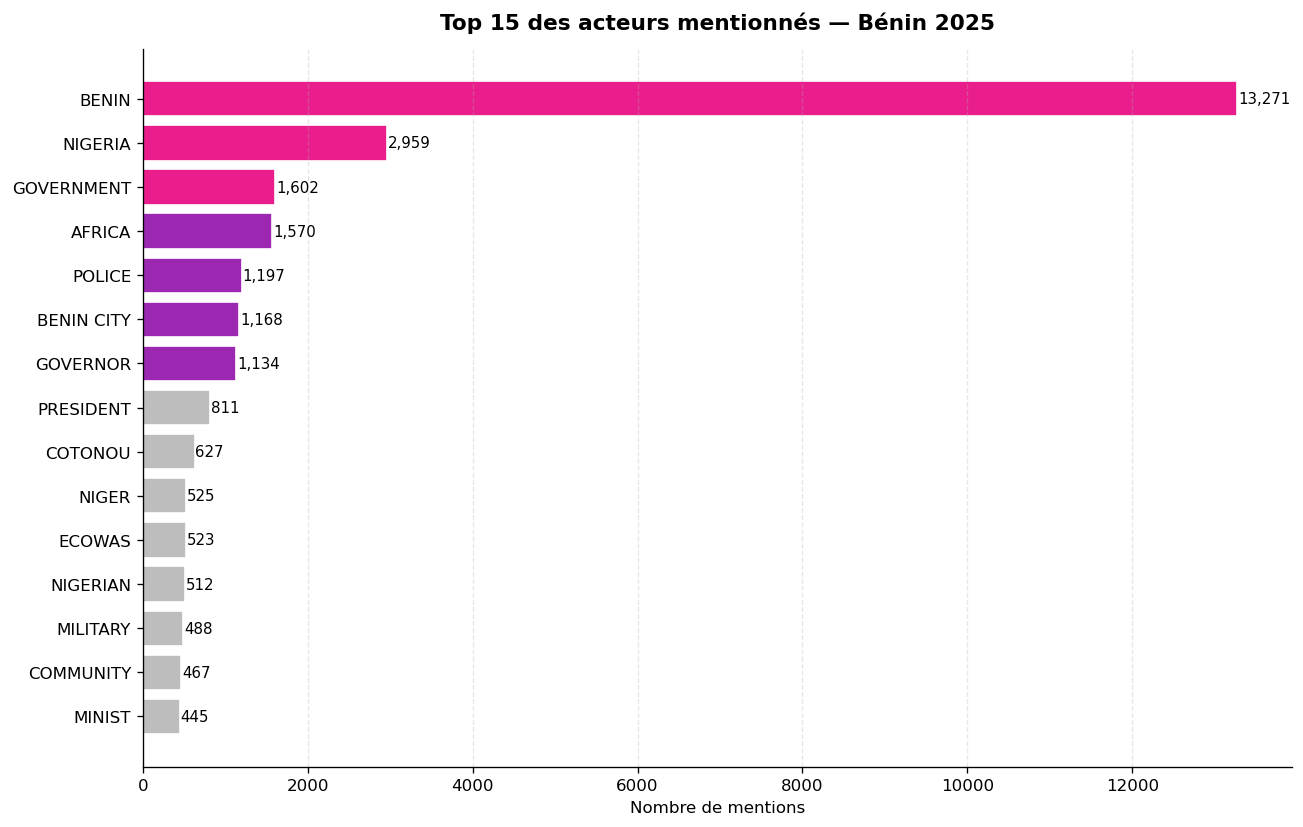

✅ viz5 sauvegardée


In [23]:
acteurs = pd.concat([
    df['Actor1Name'].dropna(),
    df['Actor2Name'].dropna()
], ignore_index=True)
acteurs = acteurs[acteurs.str.strip() != '']
top_acteurs = acteurs.value_counts().head(15)

colors_act = ['#E91E8C' if i < 3 else '#9C27B0' if i < 7 else '#BDBDBD'
              for i in range(len(top_acteurs))]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_acteurs.index[::-1], top_acteurs.values[::-1],
               color=colors_act[::-1], edgecolor='white')
for bar, val in zip(bars, top_acteurs.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 15 des acteurs mentionnés — Bénin 2025', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Nombre de mentions')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz5_top_acteurs.png', bbox_inches='tight')
plt.show()
print('✅ viz5 sauvegardée')

## 🗺️ Cellule 12 — Carte interactive des événements (Plotly)

In [24]:
import plotly.express as px

df_carte = df_geo.copy()
df_carte['taille'] = df_carte['NumArticles'].clip(1, 50)

fig_map = px.scatter_mapbox(
    df_carte.sample(min(5000, len(df_carte))),
    lat='ActionGeo_Lat', lon='ActionGeo_Long',
    color='AvgTone', size='taille',
    color_continuous_scale='RdYlGn', range_color=[-10, 10],
    hover_data={'categorie_event': True, 'Actor1Name': True,
                'AvgTone': ':.2f', 'GoldsteinScale': ':.2f',
                'ActionGeo_FullName': True, 'date': True},
    mapbox_style='carto-positron',
    center={'lat': 9.3, 'lon': 2.3}, zoom=6,
    title='Carte des événements GDELT — Bénin 2025<br>'
          '<sup>Couleur = ton médiatique | Taille = nb articles</sup>',
    height=600
)
fig_map.update_layout(margin={'r': 0, 't': 60, 'l': 0, 'b': 0})
fig_map.write_html('carte_evenements_benin.html')
fig_map.show()
print('✅ Carte interactive sauvegardée → carte_evenements_benin.html')

C:\Users\USER\AppData\Local\Temp\ipykernel_23436\3442953503.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_map = px.scatter_mapbox(


✅ Carte interactive sauvegardée → carte_evenements_benin.html


## 💡 Cellule 13 — Résumé automatique des premiers insights

In [25]:
print('=' * 60)
print('💡 PREMIERS INSIGHTS — BÉNIN 2025')
print('=' * 60)

# Insight 1 : Volume
print(f'\n📌 Insight 1 — Volume')
print(f'   {len(df):,} événements recensés')
print(f'   Période : {df["date"].min().date()} → {df["date"].max().date()}')

# Insight 2 : Événement dominant
top_event = df['categorie_event'].value_counts().index[0]
top_pct = df['categorie_event'].value_counts().iloc[0] / len(df) * 100
print(f'\n📌 Insight 2 — Événement dominant')
print(f'   "{top_event}" représente {top_pct:.1f}% des événements')

# Insight 3 : Ton global
ton_moyen = df['AvgTone'].mean()
pct_negatif = (df['AvgTone'] < 0).mean() * 100
print(f'\n📌 Insight 3 — Ton médiatique')
print(f'   Ton moyen = {ton_moyen:.2f} ({"Négatif ⚠️" if ton_moyen < 0 else "Positif ✅"})')
print(f'   {pct_negatif:.1f}% des articles ont un ton négatif')

# Insight 4 : Goldstein
gold_moyen = df['GoldsteinScale'].mean()
print(f'\n📌 Insight 4 — Stabilité (Goldstein)')
print(f'   Score moyen = {gold_moyen:.2f}')
print(f'   → {"Tendance coopérative ✅" if gold_moyen > 0 else "Tendance déstabilisatrice ⚠️"}')

# Insight 5 : Acteur dominant
top_acteur = acteurs.value_counts().index[0]
top_acteur_count = acteurs.value_counts().iloc[0]
print(f'\n📌 Insight 5 — Acteur clé')
print(f'   "{top_acteur}" : {top_acteur_count:,} mentions')

print('\n' + '=' * 60)
print('✅ Prochaine étape → ML Engineer : clustering + analyse de sentiment')
print('=' * 60)

💡 PREMIERS INSIGHTS — BÉNIN 2025

📌 Insight 1 — Volume
   30,445 événements recensés
   Période : 2025-01-01 → 2026-04-28

📌 Insight 2 — Événement dominant
   "Consultations" représente 23.7% des événements

📌 Insight 3 — Ton médiatique
   Ton moyen = -1.61 (Négatif ⚠️)
   61.1% des articles ont un ton négatif

📌 Insight 4 — Stabilité (Goldstein)
   Score moyen = 0.49
   → Tendance coopérative ✅

📌 Insight 5 — Acteur clé
   "BENIN" : 13,271 mentions

✅ Prochaine étape → ML Engineer : clustering + analyse de sentiment


## 💾 Cellule 14 — Sauvegarder les données nettoyées pour l'équipe

In [26]:
df.to_csv('data/benin_gdelt_2025_clean.csv', index=False)
df_geo.to_csv('data/benin_gdelt_2025_geo.csv', index=False)

print('✅ Fichiers de données sauvegardés :')
print(f'   data/benin_gdelt_2025_clean.csv  ({len(df):,} lignes)')
print(f'   data/benin_gdelt_2025_geo.csv    ({len(df_geo):,} lignes avec GPS)')
print('\n📋 Visualisations générées :')
for f in ['viz1_volume_evenements.png', 'viz2_types_evenements.png',
          'viz3_ton_mediatique.png', 'viz4_goldstein_categories.png',
          'viz5_top_acteurs.png', 'carte_evenements_benin.html']:
    print(f'   {f}')

✅ Fichiers de données sauvegardés :
   data/benin_gdelt_2025_clean.csv  (30,445 lignes)
   data/benin_gdelt_2025_geo.csv    (30,445 lignes avec GPS)

📋 Visualisations générées :
   viz1_volume_evenements.png
   viz2_types_evenements.png
   viz3_ton_mediatique.png
   viz4_goldstein_categories.png
   viz5_top_acteurs.png
   carte_evenements_benin.html


In [33]:
pip install streamlit plotly pydeck pandas

Note: you may need to restart the kernel to use updated packages.
